  Preparing metadata (setup.py) ... done
Libraries loaded successfully.
Mounted at /content/drive
Dataset loaded: 12680 rows | 8 columns
Date range: 1975-01-02 → 2026-04-16
Columns: ['lkr_close', 'lkr_open', 'lkr_high', 'lkr_low', 'gold_open', 'gold_high', 'gold_low', 'gold_close']

Log returns computed for both series.
USD/LKR technical indicators computed.
 SMA-10, SMA-30, EMA-10, EMA-30, RSI-14, MACD, Bollinger Bands, ATR
Gold technical indicators computed:
  SMA-10, SMA-30, RSI-14, MACD, Bollinger Band Width, ATR
Lagged gold features created:
  gold_returns_lag1 to lag5, gold_close_lag1 to lag5
Rolling volatility features created:
  lkr_vol_10, lkr_vol_30, gold_vol_10, gold_vol_30
Calendar features created: day_of_week, month, quarter
Target variables created

Shape before dropping NaN rows: (12680, 48)
Shape after dropping NaN rows:  (12646, 48)
Rows removed: 34
Effective date range: 1975-02-20 → 2026-04-15
Any remaining nulls: 0

Total features: 48

Full feature list:

  Raw OHLC

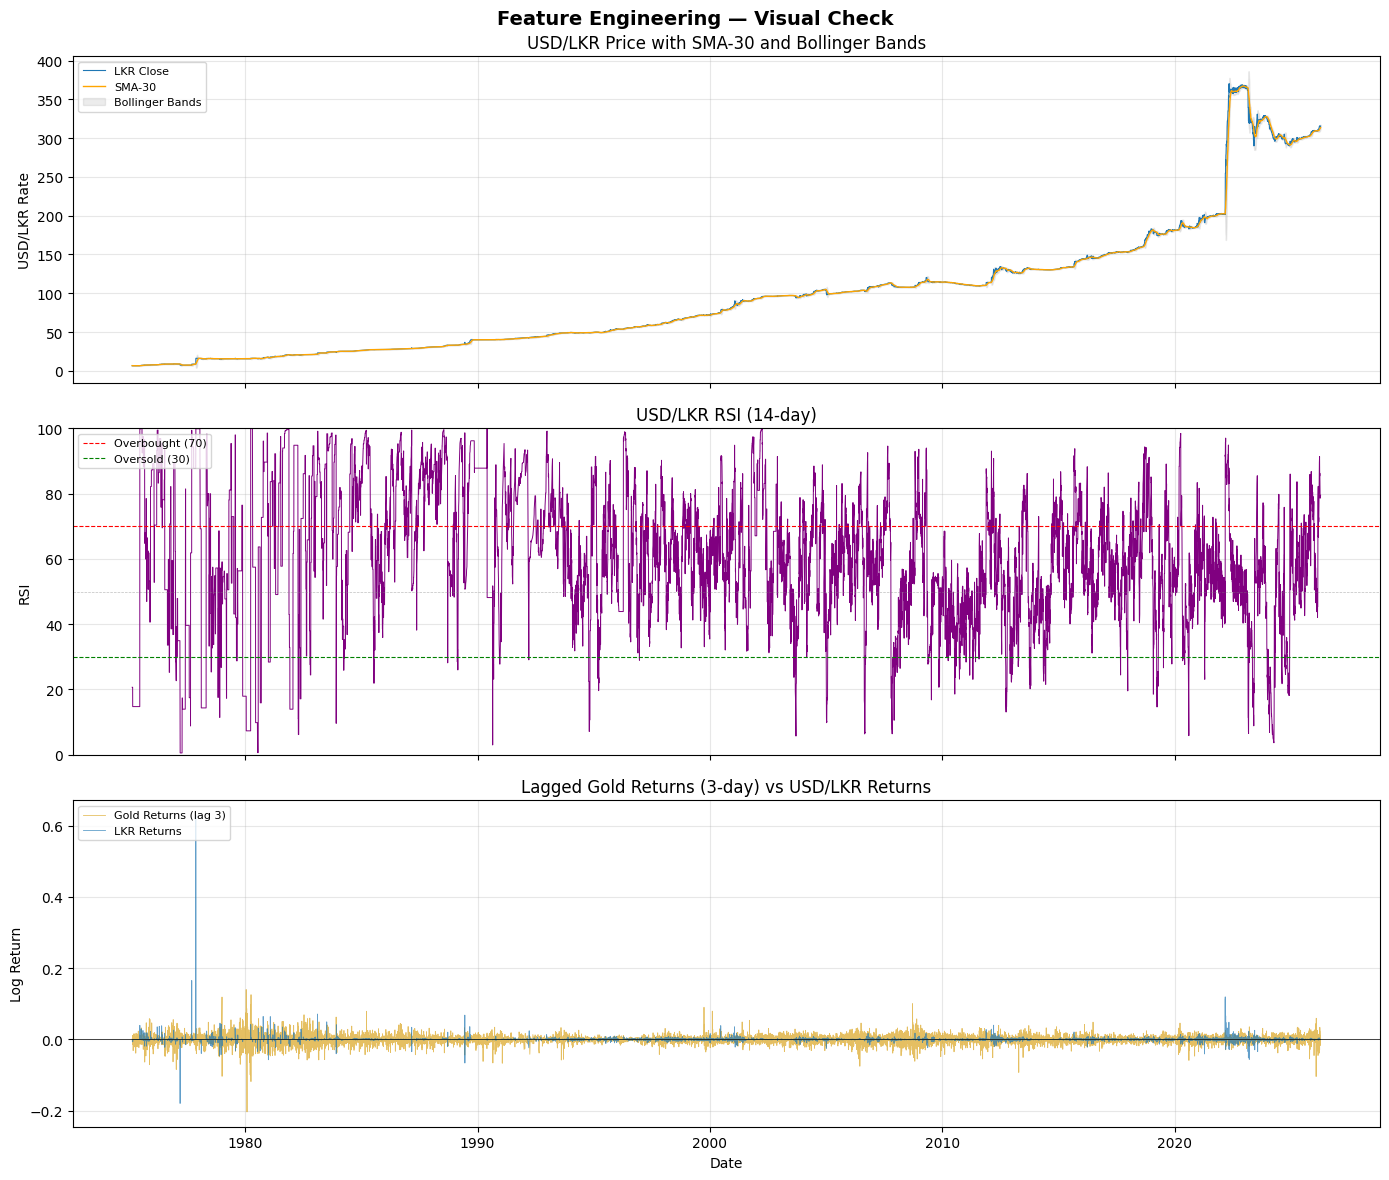

Plot saved: 03a_feature_check.png


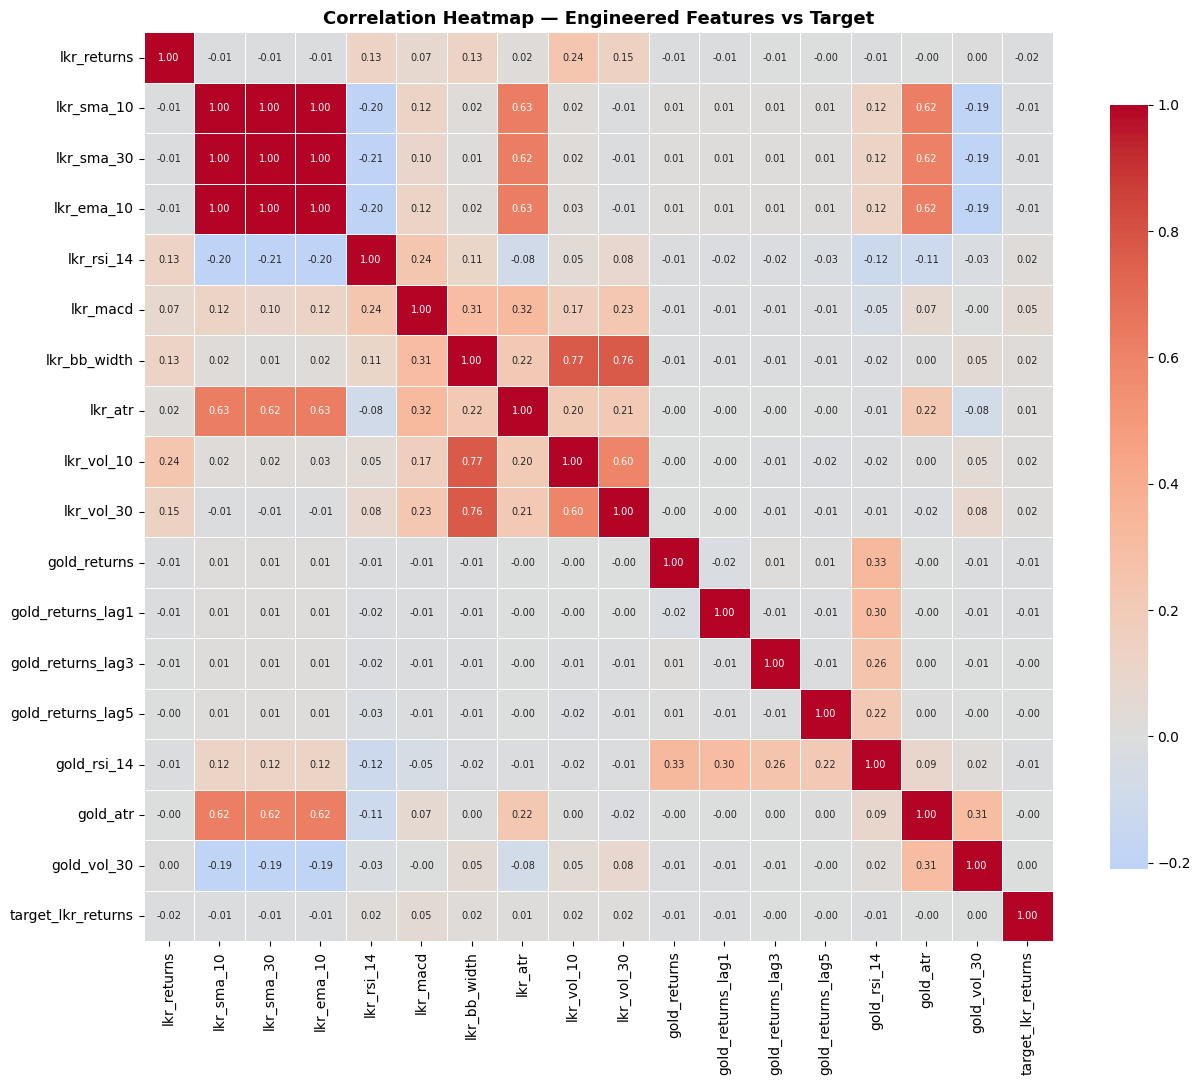


 Feature correlation with target (sorted by strength)
lkr_macd             0.0537
lkr_rsi_14           0.0249
lkr_bb_width         0.0205
lkr_returns         -0.0159
lkr_vol_30           0.0155
lkr_vol_10           0.0154
lkr_sma_30          -0.0143
gold_returns        -0.0134
lkr_sma_10          -0.0128
lkr_atr              0.0128
lkr_ema_10          -0.0127
gold_returns_lag1   -0.0113
gold_rsi_14         -0.0096
gold_returns_lag3   -0.0021
gold_vol_30          0.0013
gold_returns_lag5   -0.0007
gold_atr            -0.0005

Feature-engineered dataset saved

Final shape: 12646 rows × 48 columns
Date range:  1975-02-20 → 2026-04-15


In [1]:
!pip install ta -q
#ta-library(a financial thechnical analysis toolkit)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ta
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully.")

# LOAD CLEANED DATASET
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv(
    '/content/drive/MyDrive/MSc_Project/data/processed/usd_lkr_gold_cleaned.csv',
    index_col='Date',
    parse_dates=True
)

print(f"Dataset loaded: {df.shape[0]} rows | {df.shape[1]} columns")
print(f"Date range: {df.index.min().date()} → {df.index.max().date()}")
print(f"Columns: {df.columns.tolist()}")

# STEP 1: LOG RETURNS

#Formula: log(today's price / yesterday's price)
#This converts the non-stationary raw price series into a stationary series of daily percentage changes, confirmed by ADF tests in EDA section.

df['lkr_returns']  = np.log(df['lkr_close']  / df['lkr_close'].shift(1))
df['gold_returns'] = np.log(df['gold_close'] / df['gold_close'].shift(1))

print("\nLog returns computed for both series.")

# STEP 2: USD/LKR TECHNICAL INDICATORS

# 2.1  Simple & Exponential Moving Averages
# SMA and EMA smooth out short-term noise to reveal the underlying trend.
# EMA gives more weight to recent prices, more responsive to sudden moves.
# window -howmany days of history look back at to calcualte the average

df['lkr_sma_10'] = ta.trend.sma_indicator(df['lkr_close'], window=10)
df['lkr_sma_30'] = ta.trend.sma_indicator(df['lkr_close'], window=30)
df['lkr_ema_10'] = ta.trend.ema_indicator(df['lkr_close'], window=10)
df['lkr_ema_30'] = ta.trend.ema_indicator(df['lkr_close'], window=30)

# 2.2  RSI (Relative Strength Index)- how fast and how much the price has been moving recently
# Momentum oscillator ranging 0–100.
# Above 70 = overbought (depreciation may slow), below 30 = oversold.
df['lkr_rsi_14'] = ta.momentum.rsi(df['lkr_close'], window=14)

# 2.3  MACD (Moving Average Convergence Divergence) - measure the gap between a fast-moving average and a slow-moving avearge
# Trend-following momentum indicator showing the relationship between a 12-day and 26-day EMA. The signal line is a 9-day EMA of the MACD.
lkr_macd = ta.trend.MACD(df['lkr_close'])
df['lkr_macd']        = lkr_macd.macd()
df['lkr_macd_signal'] = lkr_macd.macd_signal()
df['lkr_macd_diff']   = lkr_macd.macd_diff()

# 2.4  Bollinger Bands - a volatility indicator that draws an envelope around the price
# Bands widen during high volatility and narrow during calm periods.
# Band width captures the current volatility regime of the LKR.
lkr_bb = ta.volatility.BollingerBands(df['lkr_close'])
df['lkr_bb_high']  = lkr_bb.bollinger_hband()
df['lkr_bb_low']   = lkr_bb.bollinger_lband()
df['lkr_bb_width'] = lkr_bb.bollinger_wband()

# 2.5  ATR (Average True Range) - how much the price typically moves in a single day
# Measures daily trading range volatility using high, low, and close.
df['lkr_atr'] = ta.volatility.average_true_range(
    df['lkr_high'], df['lkr_low'], df['lkr_close']
)

print("USD/LKR technical indicators computed.")
print(" SMA-10, SMA-30, EMA-10, EMA-30, RSI-14, MACD, Bollinger Bands, ATR")

# STEP 3: GOLD TECHNICAL INDICATORS

# Gold's own internal momentum and volatility signals may carry predictive information for LKR beyond the raw gold price level alone.

df['gold_sma_10'] = ta.trend.sma_indicator(df['gold_close'], window=10)
df['gold_sma_30'] = ta.trend.sma_indicator(df['gold_close'], window=30)
df['gold_rsi_14'] = ta.momentum.rsi(df['gold_close'], window=14)

gold_macd = ta.trend.MACD(df['gold_close'])
df['gold_macd']      = gold_macd.macd()
df['gold_macd_diff'] = gold_macd.macd_diff()

gold_bb = ta.volatility.BollingerBands(df['gold_close'])
df['gold_bb_width'] = gold_bb.bollinger_wband()

df['gold_atr'] = ta.volatility.average_true_range(
    df['gold_high'], df['gold_low'], df['gold_close']
)

print("Gold technical indicators computed:")
print("  SMA-10, SMA-30, RSI-14, MACD, Bollinger Band Width, ATR")

# STEP 4: LAGGED GOLD FEATURES

# The EDA (Section 2) Granger causality test showed that gold's predictive relationship with LKR is CRISIS-DEPENDENT rather than a constant linear effect.
# By explicitly including lagged gold features at lags 1–5,  allow the LSTM, GRU, and XGBoost models to learn any delayed or non-linear relationship that a simple Granger test cannot detect.

for lag in [1, 2, 3, 4, 5]:
    df[f'gold_returns_lag{lag}'] = df['gold_returns'].shift(lag)
    df[f'gold_close_lag{lag}']   = df['gold_close'].shift(lag)

print("Lagged gold features created:")
print("  gold_returns_lag1 to lag5, gold_close_lag1 to lag5")


# STEP 5: ROLLING VOLATILITY FEATURES

# Captures the volatility clustering observed in Section 2.
# Gives the model explicit information about how turbulent the recent period has been — important given the LKR's dramatic 2022 regime shift.

df['lkr_vol_10']  = df['lkr_returns'].rolling(10).std()
df['lkr_vol_30']  = df['lkr_returns'].rolling(30).std()
df['gold_vol_10'] = df['gold_returns'].rolling(10).std()
df['gold_vol_30'] = df['gold_returns'].rolling(30).std()

print("Rolling volatility features created:")
print("  lkr_vol_10, lkr_vol_30, gold_vol_10, gold_vol_30")


# STEP 6: CALENDAR FEATURES

# Captures any residual weekly or seasonal patterns in exchange rate behaviour.

df['day_of_week'] = df.index.dayofweek   # 0=Monday, 4=Friday
df['month']       = df.index.month
df['quarter']     = df.index.quarter

print("Calendar features created: day_of_week, month, quarter")


# STEP 7: TARGET VARIABLES

# The models predict the NEXT day's LKR values.
# Shifting by -1 aligns today's features with tomorrow's outcome.

# target_lkr_returns — next day log return (for return-based models)
df['target_lkr_returns'] = df['lkr_returns'].shift(-1)
# target_lkr_close   — next day closing price (for price-based models)
df['target_lkr_close']   = df['lkr_close'].shift(-1)

print("Target variables created")

# STEP 8: DROP NaN ROWS

# Rolling windows and lag features produce NaN rows at the start.
# The target shift produces one NaN at the very end.

print(f"\nShape before dropping NaN rows: {df.shape}")
df_features = df.dropna()
print(f"Shape after dropping NaN rows:  {df_features.shape}")
print(f"Rows removed: {df.shape[0] - df_features.shape[0]}")
print(f"Effective date range: {df_features.index.min().date()} → {df_features.index.max().date()}")
print(f"Any remaining nulls: {df_features.isnull().sum().sum()}")

# STEP 9: FEATURE SUMMARY

print(f"\nTotal features: {df_features.shape[1]}")
print("\nFull feature list:")

categories = {
    'Raw OHLC — LKR':       [c for c in df_features.columns if c.startswith('lkr_') and c in ['lkr_close','lkr_open','lkr_high','lkr_low']],
    'Raw OHLC — Gold':      [c for c in df_features.columns if c.startswith('gold_') and c in ['gold_open','gold_high','gold_low','gold_close']],
    'Returns':              ['lkr_returns','gold_returns'],
    'LKR Technical':        [c for c in df_features.columns if c.startswith('lkr_') and c not in ['lkr_close','lkr_open','lkr_high','lkr_low','lkr_returns']],
    'Gold Technical':       [c for c in df_features.columns if c.startswith('gold_') and 'lag' not in c and c not in ['gold_open','gold_high','gold_low','gold_close','gold_returns']],
    'Lagged Gold':          [c for c in df_features.columns if 'lag' in c],
    'Rolling Volatility':   [c for c in df_features.columns if 'vol' in c],
    'Calendar':             ['day_of_week','month','quarter'],
    'Target Variables':     ['target_lkr_returns','target_lkr_close'],
}

for cat, cols in categories.items():
    print(f"\n  {cat} ({len(cols)}):")
    for c in cols:
        print(f"    - {c}")

# STEP 10: VISUAL CHECK — KEY ENGINEERED FEATURES

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle('Feature Engineering — Visual Check', fontsize=14, fontweight='bold')

# USD/LKR price with Bollinger Bands and SMA-30
axes[0].plot(df_features.index, df_features['lkr_close'],
             label='LKR Close', color='#1f77b4', linewidth=0.8)
axes[0].plot(df_features.index, df_features['lkr_sma_30'],
             label='SMA-30', color='orange', linewidth=1.0)
axes[0].fill_between(df_features.index,
                     df_features['lkr_bb_low'],
                     df_features['lkr_bb_high'],
                     alpha=0.15, color='grey', label='Bollinger Bands')
axes[0].set_title('USD/LKR Price with SMA-30 and Bollinger Bands')
axes[0].set_ylabel('USD/LKR Rate')
axes[0].legend(fontsize=8, loc='upper left')
axes[0].grid(True, alpha=0.3)

# RSI with overbought/oversold lines
axes[1].plot(df_features.index, df_features['lkr_rsi_14'],
             color='purple', linewidth=0.7)
axes[1].axhline(70, color='red', linestyle='--', linewidth=0.8, label='Overbought (70)')
axes[1].axhline(30, color='green', linestyle='--', linewidth=0.8, label='Oversold (30)')
axes[1].axhline(50, color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
axes[1].set_title('USD/LKR RSI (14-day)')
axes[1].set_ylabel('RSI')
axes[1].set_ylim(0, 100)
axes[1].legend(fontsize=8, loc='upper left')
axes[1].grid(True, alpha=0.3)

# Lagged gold returns vs LKR returns
axes[2].plot(df_features.index, df_features['gold_returns_lag3'],
             color='#DAA520', linewidth=0.6, label='Gold Returns (lag 3)', alpha=0.7)
axes[2].plot(df_features.index, df_features['lkr_returns'],
             color='#1f77b4', linewidth=0.6, label='LKR Returns', alpha=0.7)
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_title('Lagged Gold Returns (3-day) vs USD/LKR Returns')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Log Return')
axes[2].legend(fontsize=8, loc='upper left')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MSc_Project/outputs/03a_feature_check.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: 03a_feature_check.png")


# STEP 11: CORRELATION HEATMAP — FEATURES VS TARGET

corr_cols = [
    'lkr_returns', 'lkr_sma_10', 'lkr_sma_30', 'lkr_ema_10',
    'lkr_rsi_14', 'lkr_macd', 'lkr_bb_width', 'lkr_atr',
    'lkr_vol_10', 'lkr_vol_30',
    'gold_returns', 'gold_returns_lag1', 'gold_returns_lag3',
    'gold_returns_lag5', 'gold_rsi_14', 'gold_atr', 'gold_vol_30',
    'target_lkr_returns'
]

plt.figure(figsize=(13, 11))
corr_matrix = df_features[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 7})
plt.title('Correlation Heatmap — Engineered Features vs Target',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MSc_Project/outputs/03b_correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print correlation with target, sorted by absolute strength
target_corr = corr_matrix['target_lkr_returns'].drop('target_lkr_returns')
target_corr = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index)
print("\n Feature correlation with target (sorted by strength)")
print(target_corr.round(4).to_string())
# Note: Weak linear correlations with the target are expected and confirm the non-linear, time-varying nature of the relationship identified in EDA Section.
# These features may still carry significant non-linear signal that LSTM, GRU, and XGBoost can learn.

# STEP 12: SAVE FEATURE-ENGINEERED DATASET

df_features.to_csv(
    '/content/drive/MyDrive/MSc_Project/data/processed/usd_lkr_gold_features.csv'
)
print("\nFeature-engineered dataset saved")
print(f"\nFinal shape: {df_features.shape[0]} rows × {df_features.shape[1]} columns")
print(f"Date range:  {df_features.index.min().date()} → {df_features.index.max().date()}")